In [4]:
logs_list = [
    "recal_PIT_runner_20260402_133325.log",
    "recal_CKMEKDO_runner_20260402_133853.log",
    "recal_PIT_runner_20260402_134339.log",
    "recal_CKMEKDO_runner_20260402_134955.log"
]

basemodel_list = ["drf", "drf", "mdn", "mdn"]

recal_list = ["PIT", "CKME", "PIT", "CKME"], 

In [1]:
import pandas as pd
import re
import io

def parse_logs_to_df(file_path):
    # Regex to capture the model run details
    # Example target: ... INFO: run CKMEKDO on ../models/mdn/exported_predictions/: tmp4/uci_datasets/kin8nm/split_2
    run_pattern = re.compile(
        r"run\s+(?P<model_name>\S+)\s+on\s+.*?models/(?P<base_model_name>[^/]+)/exported_predictions/:\s+(?P<tmp_dir>[^/]+)/(?P<data_repo>[^/]+)/(?P<dataset>[^/]+)/(?P<split_name>\S+)"
    )
    
    # Regex to capture the wall clock time
    # Example target: [ Info: WALL_CLOCK_TIME: 67.711243152
    time_pattern = re.compile(
        r"WALL_CLOCK_TIME:\s+(?P<wall_clock_time>[\d\.]+)"
    )

    records = []
    current_record = {}

    # Open and process the file
    with open(file_path, 'r') as file:
        for line in file:
            # Look for the 'run ...' line
            run_match = run_pattern.search(line)
            if run_match:
                current_record = run_match.groupdict()
                continue
            
            # Look for the 'WALL_CLOCK_TIME' line
            time_match = time_pattern.search(line)
            if time_match and current_record:
                current_record['WALL_CLOCK_TIME'] = float(time_match.group('wall_clock_time'))
                records.append(current_record)
                current_record = {}  # Reset for the next block of logs

    # Convert the list of dictionaries into a Pandas DataFrame
    df = pd.DataFrame(records)
    
    # Enforce the requested column order if the dataframe is not empty
    if not df.empty:
        cols = ['WALL_CLOCK_TIME', 'model_name', 'base_model_name', 'tmp_dir', 'data_repo', 'dataset', 'split_name']
        df = df[cols]
        
    return df


In [11]:
dfs = []
for log_name in logs_list:
    path = "../logs/" + log_name
    df = parse_logs_to_df(path)
    dfs.append(df)

In [35]:
df = pd.concat(dfs)
df['recalibration_name'] = df['model_name'].replace('CKMEKDO', 'CKME')

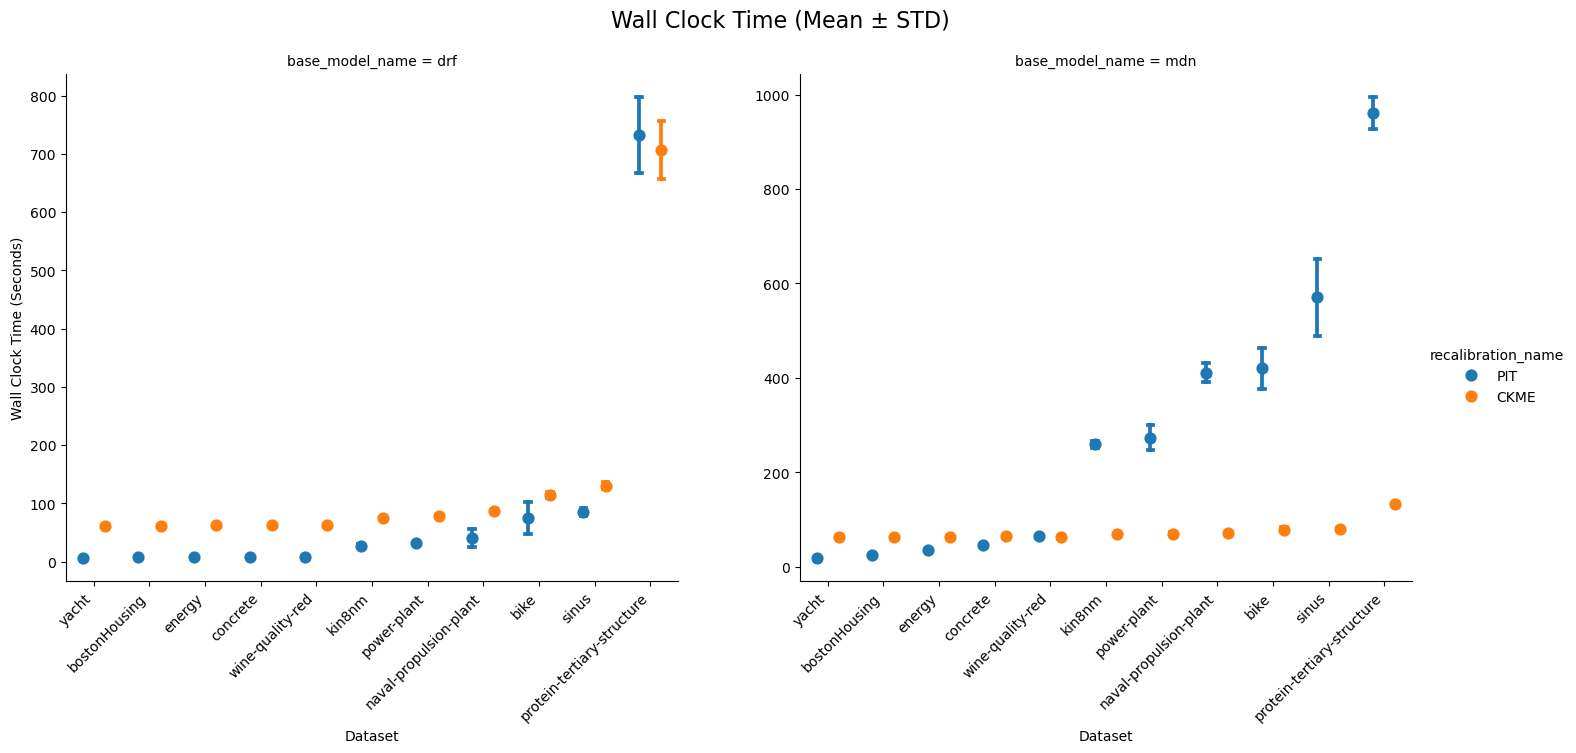

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define your custom order as a list (replace these with your actual dataset names)
custom_dataset_order = ["yacht", "bostonHousing", "energy", "concrete", "wine-quality-red", "kin8nm", "power-plant", 
         "naval-propulsion-plant", "bike", "sinus", "protein-tertiary-structure"]

# Create the point plot (scatter with std whiskers)
g = sns.catplot(
    data=df,
    x='dataset',
    y='WALL_CLOCK_TIME',
    hue='recalibration_name',
    col='base_model_name',
    kind='point',
    order=custom_dataset_order,  # <--- Add your custom list here
    errorbar='sd',        
    linestyle='none',     
    capsize=0.1,          
    dodge=0.4,            
    height=6,
    aspect=1.2,
    sharey=False          
)

# Rotate x-axis labels
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Title and labels
g.fig.suptitle("Wall Clock Time (Mean ± STD)", y=1.05, fontsize=16)
g.set_axis_labels("Dataset", "Wall Clock Time (Seconds)")

# Save the plot
plt.savefig('wall_clock_time_custom_order.pdf', bbox_inches='tight')
plt.savefig('wall_clock_time_custom_order.svg', bbox_inches='tight')